
🎨 2D TRANSFORMATION STUDIO

This tool visualizes how linear transformations affect 2D shapes.


                  🎯 SCALING TRANSFORMATION                  

ANALYSIS: Scale (x2, y0.5)
Matrix:
  [2.000, 0.000]
  [0.000, 0.500]

Determinant: 1.000
  → Area scales by factor 1.000
  → Preserves orientation
  → Invertible

Eigenvalues (real): 2.000, 0.500
  → Stretches by factor 2.000

Eigenvectors (direction of pure stretch):
  λ1=2.000: [1.000, 0.000]
  λ2=0.500: [0.000, 1.000]


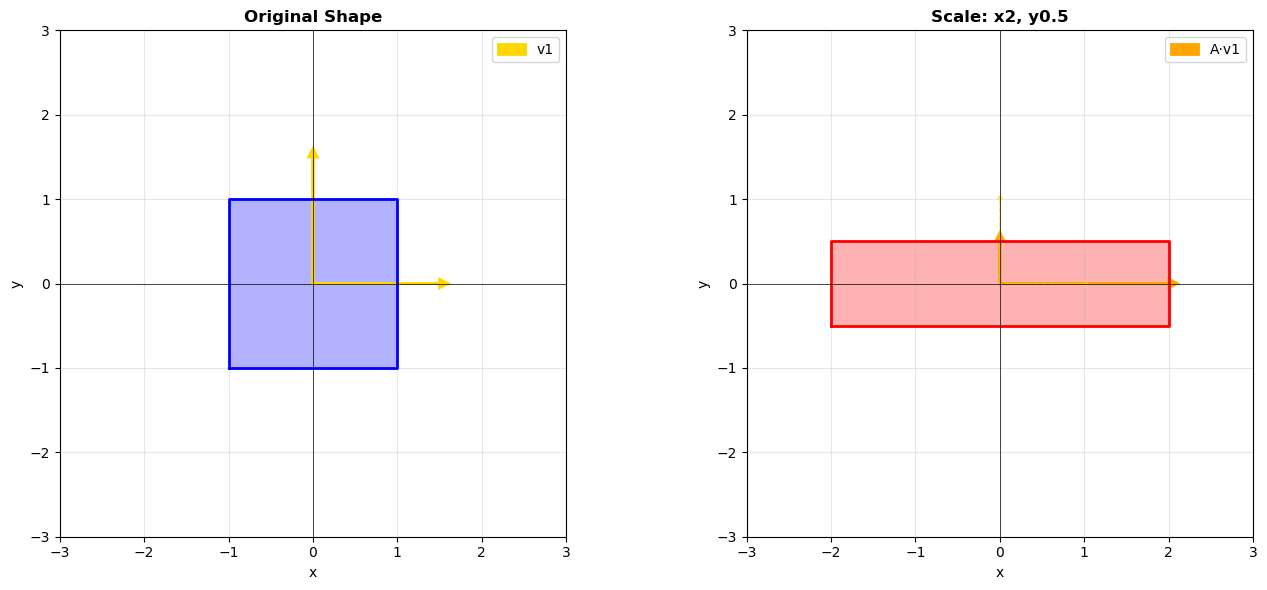


                 🎯 ROTATION TRANSFORMATION                  

ANALYSIS: Rotation (45°)
Matrix:
  [0.707, -0.707]
  [0.707, 0.707]

Determinant: 1.000
  → Area scales by factor 1.000
  → Preserves orientation
  → Invertible

Eigenvalues (complex): 0.707+0.707j, 0.707-0.707j
  → Complex eigenvalues indicate ROTATION!
  → No real eigenvectors exist
  → Magnitude = 1.000 (stretch factor)
  → Angle = 45.0°


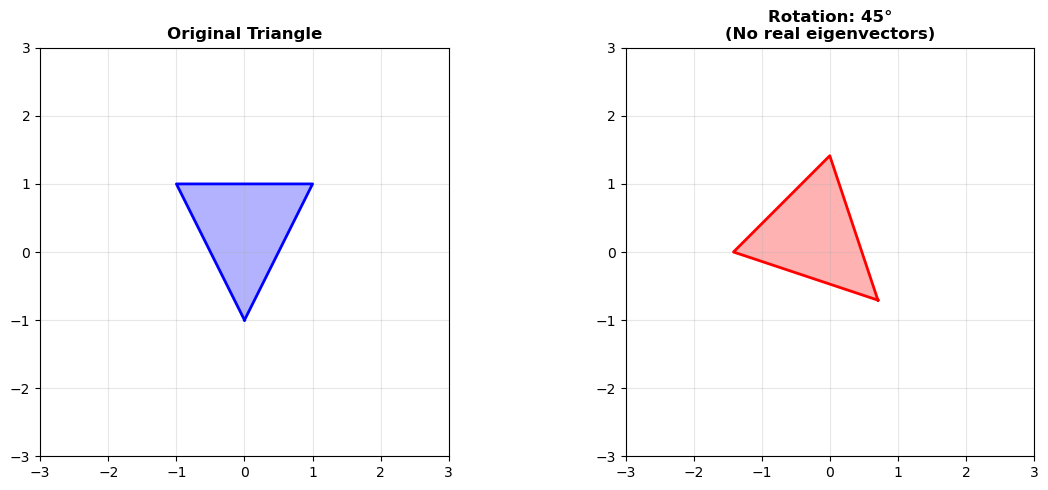


                 🎯 SHEARING TRANSFORMATION                  

ANALYSIS: Shear (x changes with y)
Matrix:
  [1.000, 0.500]
  [0.000, 1.000]

Determinant: 1.000
  → Area scales by factor 1.000
  → Preserves orientation
  → Invertible

Eigenvalues (real): 1.000, 1.000
  → Stretches by factor 1.000

Eigenvectors (direction of pure stretch):
  λ1=1.000: [1.000, 0.000]
  λ2=1.000: [-1.000, 0.000]


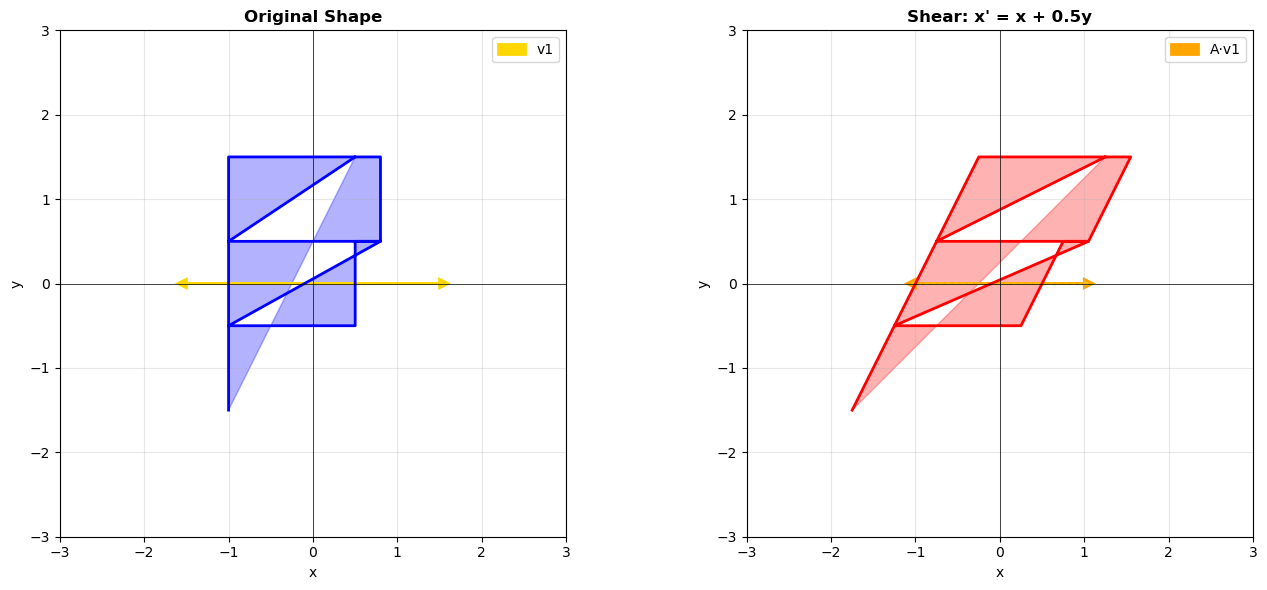


                🎯 REFLECTION TRANSFORMATION                 

ANALYSIS: Reflection across x-axis
Matrix:
  [1.000, 0.000]
  [0.000, -1.000]

Determinant: -1.000
  → Area scales by factor 1.000
  → Flips orientation
  → Invertible

Eigenvalues (real): 1.000, -1.000
  → Stretches by factor 1.000

Eigenvectors (direction of pure stretch):
  λ1=1.000: [1.000, 0.000]
  λ2=-1.000: [0.000, 1.000]


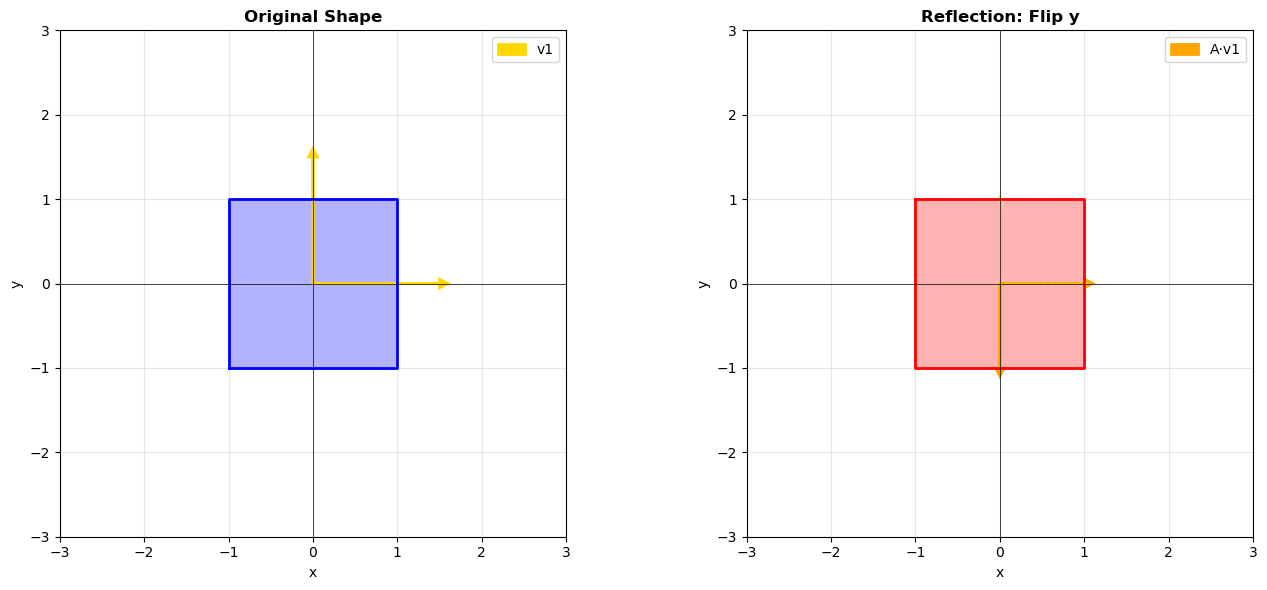


                🎯 PROJECTION TRANSFORMATION                 

ANALYSIS: Projection onto x-axis
Matrix:
  [1.000, 0.000]
  [0.000, 0.000]

Determinant: 0.000
  → Area scales by factor 0.000
  → Flips orientation
  → NOT invertible

Eigenvalues (real): 1.000, 0.000
  → Stretches by factor 1.000

Eigenvectors (direction of pure stretch):
  λ1=1.000: [1.000, 0.000]
  λ2=0.000: [0.000, 1.000]


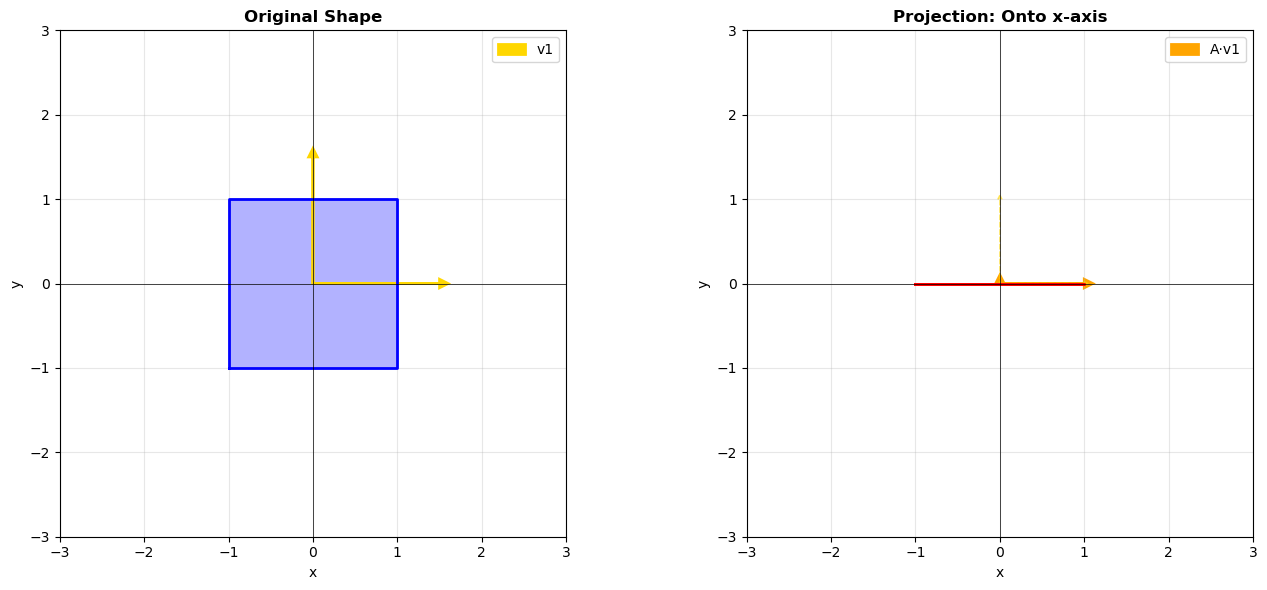


                 🎯 CHAINING TRANSFORMATIONS                 

Applying: Rotate 45° → Scale (x2, y0.5)


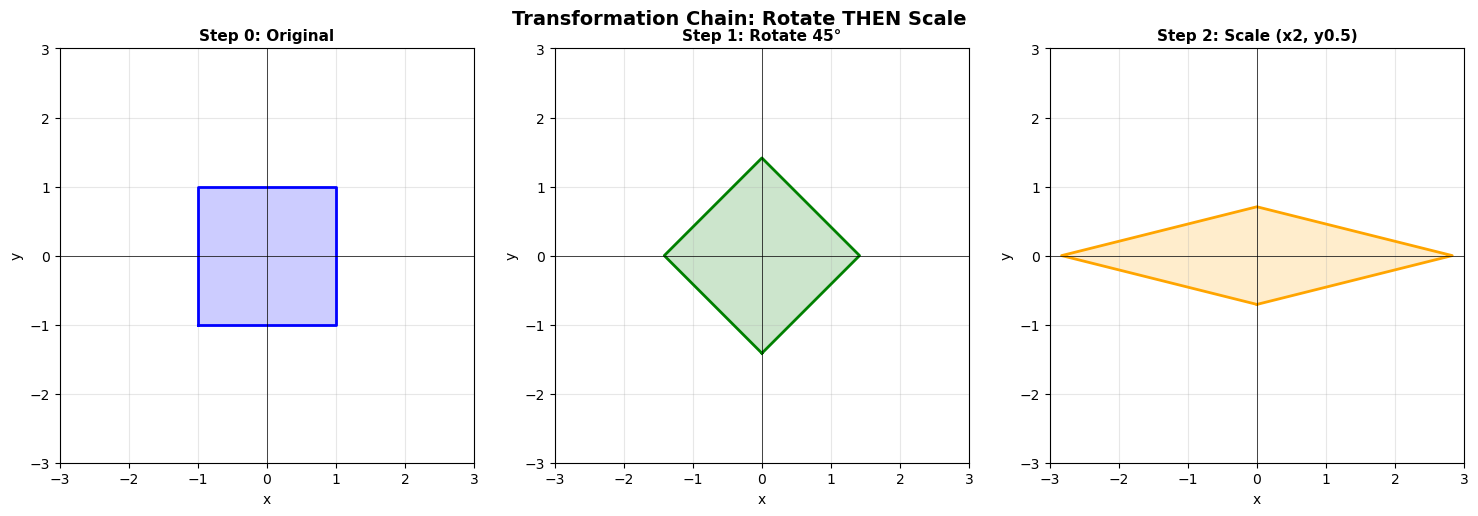


                    🎯 WHY ORDER MATTERS                     


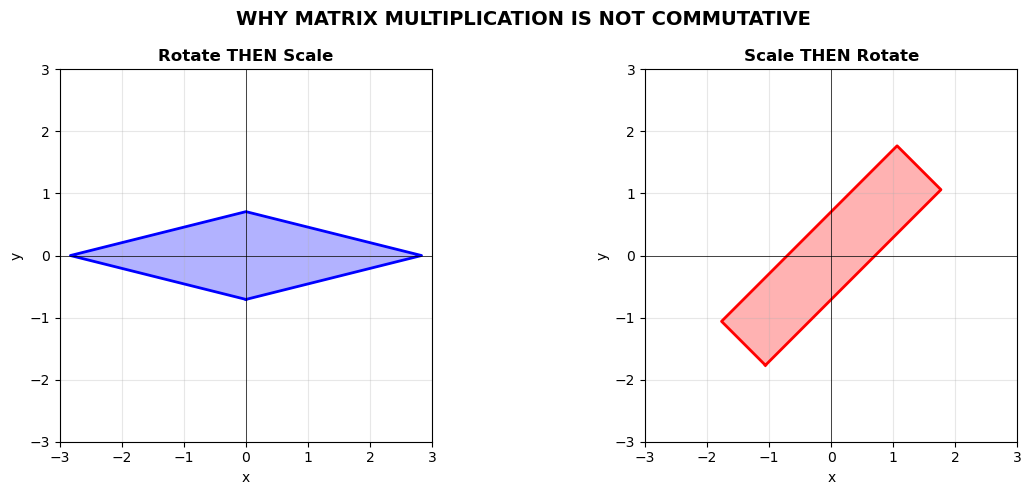


DEMONSTRATION: Matrix multiplication is NOT commutative
The matrices are different! Order MATTERS!

                  🎯 INVERSE TRANSFORMATION                  

INVERSE DEMONSTRATION: Scale(2,2) then Rotate(30°)
Successfully recovered: True


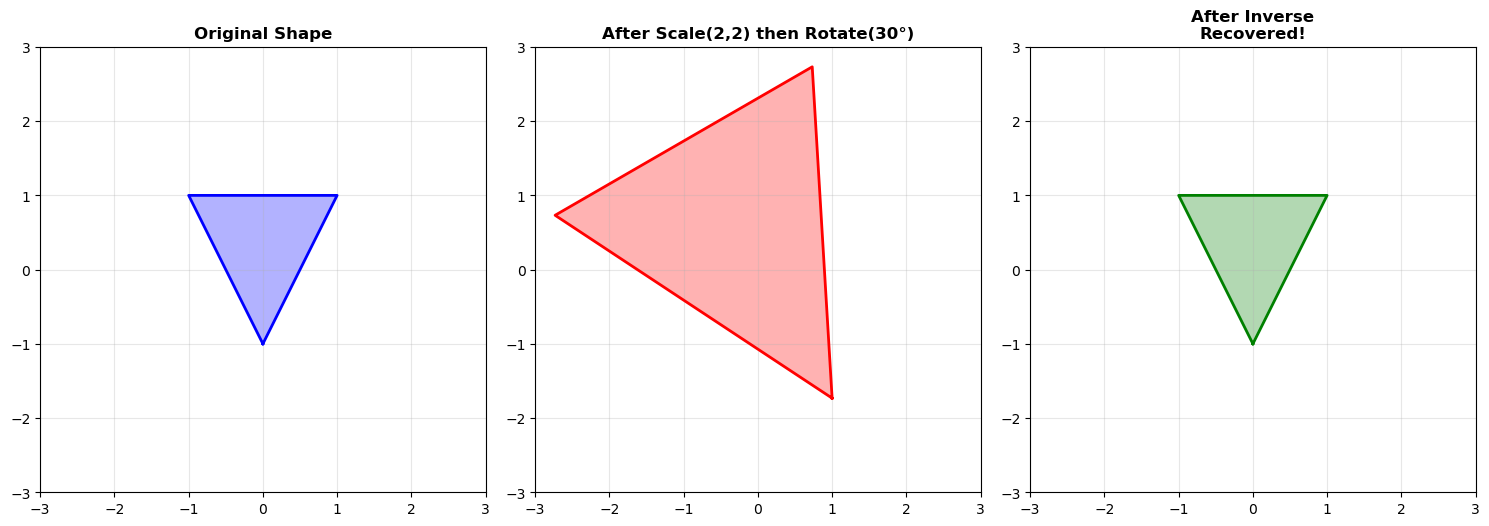


✅ PROJECT COMPLETE!

You've demonstrated:
  ✓ Scaling, Rotation, Shear, Reflection, Projection
  ✓ Determinant, eigenvalues, eigenvectors analysis
  ✓ Visual before/after plots
  ✓ Chaining transformations (order matters)
  ✓ Non-commutative proof
  ✓ Inverse transformation recovery


In [10]:
"""
Project 3: 2D Transformation Studio
Author: Fonyuy Gita
Course: Linear Algebra for Deep Learning

Interactive tool to visualize linear transformations on 2D shapes.
"""

import numpy as np
import matplotlib.pyplot as plt

# ============================================
# PART 1: SHAPE DEFINITIONS
# ============================================

def create_square():
    """
    Create a square centered at origin with side length 2.
    Returns: 2×N matrix where each column is a point (x,y)
    """
    points = np.array([
        [-1, -1],  # Bottom-left
        [ 1, -1],  # Bottom-right
        [ 1,  1],  # Top-right
        [-1,  1],  # Top-left
        [-1, -1]   # Back to start
    ]).T
    return points

def create_triangle():
    """
    Create a triangle centered at origin.
    Returns: 2×N matrix where each column is a point (x,y)
    """
    points = np.array([
        [0, -1],   # Bottom point
        [1,  1],   # Top-right
        [-1, 1],   # Top-left
        [0, -1]    # Back to start
    ]).T
    return points

def create_letter_f():
    """
    Create points forming the letter 'F' (good for showing shear).
    Returns: 2×N matrix where each column is a point (x,y)
    """
    points = np.array([
        [-1, -1.5], [-1, -0.5], [-1, 0.5], [-1, 1.5],
        [-1, 1.5], [0.5, 1.5],
        [-1, 0.5], [0.8, 0.5],
        [-1, -0.5], [0.5, -0.5],
        [0.5, -0.5], [0.5, 0.5], [0.8, 0.5], [0.8, 1.5], [0.5, 1.5]
    ]).T
    return points

# ============================================
# PART 2: TRANSFORMATION MATRICES
# ============================================

def scale_matrix(sx, sy):
    """Scale x by sx, y by sy"""
    return np.array([[sx, 0],
                     [0, sy]])

def rotation_matrix(theta_degrees):
    """Rotate by theta degrees counter-clockwise"""
    theta_rad = np.radians(theta_degrees)
    cos_t = np.cos(theta_rad)
    sin_t = np.sin(theta_rad)
    return np.array([[cos_t, -sin_t],
                     [sin_t, cos_t]])

def shear_matrix(kx, ky):
    """Shear: x changes with y, y changes with x"""
    return np.array([[1, kx],
                     [ky, 1]])

def reflection_matrix(axis='x'):
    """Reflect across x-axis or y-axis"""
    if axis == 'x':
        return np.array([[1, 0],
                         [0, -1]])
    elif axis == 'y':
        return np.array([[-1, 0],
                         [0, 1]])
    else:
        raise ValueError("axis must be 'x' or 'y'")

def projection_matrix(axis='x'):
    """Project onto x-axis or y-axis (collapses one dimension)"""
    if axis == 'x':
        return np.array([[1, 0],
                         [0, 0]])
    elif axis == 'y':
        return np.array([[0, 0],
                         [0, 1]])
    else:
        raise ValueError("axis must be 'x' or 'y'")

# ============================================
# PART 3: TRANSFORMATION ANALYSIS
# ============================================

def analyze_transformation(A):
    """Analyze a transformation matrix."""
    det = np.linalg.det(A)
    eigenvalues, eigenvectors = np.linalg.eig(A)
    invertible = abs(det) > 1e-10
    
    return {
        'matrix': A,
        'determinant': det,
        'eigenvalues': eigenvalues,
        'eigenvectors': eigenvectors,
        'invertible': invertible,
        'area_scale': abs(det),
        'preserves_orientation': det > 0
    }

def print_analysis(A, name):
    """Print formatted analysis of transformation (handles complex eigenvalues)"""
    analysis = analyze_transformation(A)
    
    print(f"\n{'='*50}")
    print(f"ANALYSIS: {name}")
    print(f"{'='*50}")
    print(f"Matrix:")
    print(f"  [{analysis['matrix'][0,0]:.3f}, {analysis['matrix'][0,1]:.3f}]")
    print(f"  [{analysis['matrix'][1,0]:.3f}, {analysis['matrix'][1,1]:.3f}]")
    print(f"\nDeterminant: {analysis['determinant']:.3f}")
    print(f"  → Area scales by factor {analysis['area_scale']:.3f}")
    print(f"  → {'Preserves' if analysis['preserves_orientation'] else 'Flips'} orientation")
    print(f"  → {'Invertible' if analysis['invertible'] else 'NOT invertible'}")
    
    ev1, ev2 = analysis['eigenvalues']
    if np.isreal(ev1) and np.isreal(ev2):
        print(f"\nEigenvalues (real): {ev1.real:.3f}, {ev2.real:.3f}")
        print(f"  → Stretches by factor {max(abs(ev1.real), abs(ev2.real)):.3f}")
        print(f"\nEigenvectors (direction of pure stretch):")
        for i in range(2):
            vec = analysis['eigenvectors'][:, i]
            if np.isreal(vec).all():
                print(f"  λ{i+1}={analysis['eigenvalues'][i].real:.3f}: [{vec[0].real:.3f}, {vec[1].real:.3f}]")
    else:
        print(f"\nEigenvalues (complex): {ev1:.3f}, {ev2:.3f}")
        print(f"  → Complex eigenvalues indicate ROTATION!")
        print(f"  → No real eigenvectors exist")
        print(f"  → Magnitude = {np.abs(ev1):.3f} (stretch factor)")
        print(f"  → Angle = {np.degrees(np.angle(ev1)):.1f}°")

# ============================================
# PART 4: VISUALIZATION
# ============================================

def plot_with_eigenvectors(original_points, transformed_points, A, title):
    """Plot transformation with eigenvector arrows (only for real eigenvalues)."""
    analysis = analyze_transformation(A)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Original plot
    axes[0].plot(original_points[0], original_points[1], 'b-', linewidth=2)
    axes[0].fill(original_points[0], original_points[1], alpha=0.3, color='blue')
    
    # Check if eigenvalues are real
    are_real = np.all(np.isreal(analysis['eigenvalues']))
    
    if are_real:
        for i, vec in enumerate(analysis['eigenvectors'].T):
            if np.isreal(vec).all():
                vec_real = vec.real
                axes[0].arrow(0, 0, vec_real[0]*1.5, vec_real[1]*1.5, 
                             head_width=0.1, head_length=0.1, fc='gold', ec='gold',
                             linewidth=2, label=f'v{i+1}' if i==0 else "")
        axes[0].legend()
    else:
        axes[0].text(0.5, -2, "Complex eigenvalues\n(no real eigenvectors)", 
                    ha='center', fontsize=10, color='gray')
    
    axes[0].set_title('Original Shape', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('x')
    axes[0].set_ylabel('y')
    axes[0].grid(True, alpha=0.3)
    axes[0].set_aspect('equal')
    axes[0].axhline(0, color='black', linewidth=0.5)
    axes[0].axvline(0, color='black', linewidth=0.5)
    axes[0].set_xlim(-3, 3)
    axes[0].set_ylim(-3, 3)
    
    # Transformed plot
    axes[1].plot(transformed_points[0], transformed_points[1], 'r-', linewidth=2)
    axes[1].fill(transformed_points[0], transformed_points[1], alpha=0.3, color='red')
    
    if are_real:
        for i, vec in enumerate(analysis['eigenvectors'].T):
            if np.isreal(vec).all():
                vec_real = vec.real
                transformed_vec = A @ vec_real
                axes[1].arrow(0, 0, transformed_vec[0], transformed_vec[1], 
                             head_width=0.1, head_length=0.1, fc='orange', ec='orange',
                             linewidth=2, label=f'A·v{i+1}' if i==0 else "")
                axes[1].arrow(0, 0, vec_real[0], vec_real[1], 
                             head_width=0.05, head_length=0.05, fc='gold', ec='gold',
                             alpha=0.5, linestyle='--')
        axes[1].legend()
    
    axes[1].set_title(title, fontsize=12, fontweight='bold')
    axes[1].set_xlabel('x')
    axes[1].set_ylabel('y')
    axes[1].grid(True, alpha=0.3)
    axes[1].set_aspect('equal')
    axes[1].axhline(0, color='black', linewidth=0.5)
    axes[1].axvline(0, color='black', linewidth=0.5)
    axes[1].set_xlim(-3, 3)
    axes[1].set_ylim(-3, 3)
    
    plt.tight_layout()
    plt.show()
    return analysis

# ============================================
# PART 5: TRANSFORMATION CHAINING
# ============================================

def chain_transformations(transformations, points):
    """Apply multiple transformations in sequence."""
    current = points.copy()
    history = [('Original', current.copy())]
    
    for A, name in transformations:
        current = A @ current
        history.append((name, current.copy()))
    
    return history

def visualize_chain(history, title="Transformation Chain"):
    """Visualize each step in a transformation chain."""
    n_steps = len(history)
    cols = min(3, n_steps)
    rows = (n_steps + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 5*rows))
    if rows == 1 and cols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    colors = ['blue', 'green', 'orange', 'red', 'purple', 'brown']
    
    for idx, (name, points) in enumerate(history):
        ax = axes[idx]
        ax.plot(points[0], points[1], '-', linewidth=2, color=colors[idx % len(colors)])
        ax.fill(points[0], points[1], alpha=0.2, color=colors[idx % len(colors)])
        ax.set_title(f'Step {idx}: {name}', fontsize=11, fontweight='bold')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal')
        ax.axhline(0, color='black', linewidth=0.5)
        ax.axvline(0, color='black', linewidth=0.5)
        ax.set_xlim(-3, 3)
        ax.set_ylim(-3, 3)
    
    for idx in range(len(history), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

def demonstrate_non_commutative():
    """Demonstrate that matrix multiplication is not commutative."""
    square = create_square()
    A_rotate = rotation_matrix(45)
    A_scale = scale_matrix(2, 0.5)
    
    rotate_then_scale = A_scale @ A_rotate @ square
    scale_then_rotate = A_rotate @ A_scale @ square
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    axes[0].plot(rotate_then_scale[0], rotate_then_scale[1], 'b-', linewidth=2)
    axes[0].fill(rotate_then_scale[0], rotate_then_scale[1], alpha=0.3, color='blue')
    axes[0].set_title('Rotate THEN Scale', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('x')
    axes[0].set_ylabel('y')
    axes[0].grid(True, alpha=0.3)
    axes[0].set_aspect('equal')
    axes[0].axhline(0, color='black', linewidth=0.5)
    axes[0].axvline(0, color='black', linewidth=0.5)
    axes[0].set_xlim(-3, 3)
    axes[0].set_ylim(-3, 3)
    
    axes[1].plot(scale_then_rotate[0], scale_then_rotate[1], 'r-', linewidth=2)
    axes[1].fill(scale_then_rotate[0], scale_then_rotate[1], alpha=0.3, color='red')
    axes[1].set_title('Scale THEN Rotate', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('x')
    axes[1].set_ylabel('y')
    axes[1].grid(True, alpha=0.3)
    axes[1].set_aspect('equal')
    axes[1].axhline(0, color='black', linewidth=0.5)
    axes[1].axvline(0, color='black', linewidth=0.5)
    axes[1].set_xlim(-3, 3)
    axes[1].set_ylim(-3, 3)
    
    plt.suptitle('WHY MATRIX MULTIPLICATION IS NOT COMMUTATIVE', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*60)
    print("DEMONSTRATION: Matrix multiplication is NOT commutative")
    print("="*60)
    print("The matrices are different! Order MATTERS!")

# ============================================
# PART 6: INVERSE DEMONSTRATION
# ============================================

def demonstrate_inverse(shape_points, A, name):
    """Apply transformation then its inverse to recover original shape."""
    print(f"\n{'='*60}")
    print(f"INVERSE DEMONSTRATION: {name}")
    print(f"{'='*60}")
    
    transformed = A @ shape_points
    A_inv = np.linalg.inv(A)
    recovered = A_inv @ transformed
    is_close = np.allclose(shape_points, recovered)
    
    print(f"Successfully recovered: {is_close}")
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].plot(shape_points[0], shape_points[1], 'b-', linewidth=2)
    axes[0].fill(shape_points[0], shape_points[1], alpha=0.3, color='blue')
    axes[0].set_title('Original Shape', fontsize=12, fontweight='bold')
    axes[0].set_aspect('equal')
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xlim(-3, 3)
    axes[0].set_ylim(-3, 3)
    
    axes[1].plot(transformed[0], transformed[1], 'r-', linewidth=2)
    axes[1].fill(transformed[0], transformed[1], alpha=0.3, color='red')
    axes[1].set_title(f'After {name}', fontsize=12, fontweight='bold')
    axes[1].set_aspect('equal')
    axes[1].grid(True, alpha=0.3)
    axes[1].set_xlim(-3, 3)
    axes[1].set_ylim(-3, 3)
    
    color = 'green' if is_close else 'orange'
    axes[2].plot(recovered[0], recovered[1], '-', linewidth=2, color=color)
    axes[2].fill(recovered[0], recovered[1], alpha=0.3, color=color)
    axes[2].set_title(f'After Inverse\n{"" if is_close else "NOT "}Recovered!', fontsize=12, fontweight='bold')
    axes[2].set_aspect('equal')
    axes[2].grid(True, alpha=0.3)
    axes[2].set_xlim(-3, 3)
    axes[2].set_ylim(-3, 3)
    
    plt.tight_layout()
    plt.show()
    return is_close

# ============================================
# PART 7: MAIN FUNCTION
# ============================================

def main():
    """Main function to run the 2D Transformation Studio."""
    print("\n" + "="*60)
    print("🎨 2D TRANSFORMATION STUDIO")
    print("="*60)
    print("\nThis tool visualizes how linear transformations affect 2D shapes.\n")
    
    # Create shapes
    square = create_square()
    triangle = create_triangle()
    letter_f = create_letter_f()
    
    # DEMO 1: SCALING
    print("\n" + "🎯 SCALING TRANSFORMATION".center(60))
    A_scale = scale_matrix(2, 0.5)
    print_analysis(A_scale, "Scale (x2, y0.5)")
    transformed_scale = A_scale @ square
    plot_with_eigenvectors(square, transformed_scale, A_scale, "Scale: x2, y0.5")
    
    # DEMO 2: ROTATION
    print("\n" + "🎯 ROTATION TRANSFORMATION".center(60))
    A_rotate = rotation_matrix(45)
    print_analysis(A_rotate, "Rotation (45°)")
    transformed_rotate = A_rotate @ triangle
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].plot(triangle[0], triangle[1], 'b-', linewidth=2)
    axes[0].fill(triangle[0], triangle[1], alpha=0.3, color='blue')
    axes[0].set_title('Original Triangle', fontsize=12, fontweight='bold')
    axes[0].set_aspect('equal')
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xlim(-3, 3)
    axes[0].set_ylim(-3, 3)
    
    axes[1].plot(transformed_rotate[0], transformed_rotate[1], 'r-', linewidth=2)
    axes[1].fill(transformed_rotate[0], transformed_rotate[1], alpha=0.3, color='red')
    axes[1].set_title('Rotation: 45°\n(No real eigenvectors)', fontsize=12, fontweight='bold')
    axes[1].set_aspect('equal')
    axes[1].grid(True, alpha=0.3)
    axes[1].set_xlim(-3, 3)
    axes[1].set_ylim(-3, 3)
    
    plt.tight_layout()
    plt.show()
    
    # DEMO 3: SHEARING
    print("\n" + "🎯 SHEARING TRANSFORMATION".center(60))
    A_shear = shear_matrix(0.5, 0)
    print_analysis(A_shear, "Shear (x changes with y)")
    transformed_shear = A_shear @ letter_f
    plot_with_eigenvectors(letter_f, transformed_shear, A_shear, "Shear: x' = x + 0.5y")
    
    # DEMO 4: REFLECTION
    print("\n" + "🎯 REFLECTION TRANSFORMATION".center(60))
    A_reflect = reflection_matrix('x')
    print_analysis(A_reflect, "Reflection across x-axis")
    transformed_reflect = A_reflect @ square
    plot_with_eigenvectors(square, transformed_reflect, A_reflect, "Reflection: Flip y")
    
    # DEMO 5: PROJECTION
    print("\n" + "🎯 PROJECTION TRANSFORMATION".center(60))
    A_project = projection_matrix('x')
    print_analysis(A_project, "Projection onto x-axis")
    transformed_project = A_project @ square
    plot_with_eigenvectors(square, transformed_project, A_project, "Projection: Onto x-axis")
    
    # DEMO 6: CHAINING
    print("\n" + "🎯 CHAINING TRANSFORMATIONS".center(60))
    print("\nApplying: Rotate 45° → Scale (x2, y0.5)")
    transformations = [
        (rotation_matrix(45), "Rotate 45°"),
        (scale_matrix(2, 0.5), "Scale (x2, y0.5)")
    ]
    chain_history = chain_transformations(transformations, square)
    visualize_chain(chain_history, "Transformation Chain: Rotate THEN Scale")
    
    # DEMO 7: NON-COMMUTATIVE
    print("\n" + "🎯 WHY ORDER MATTERS".center(60))
    demonstrate_non_commutative()
    
    # DEMO 8: INVERSE
    print("\n" + "🎯 INVERSE TRANSFORMATION".center(60))
    A_test = scale_matrix(2, 2) @ rotation_matrix(30)
    demonstrate_inverse(triangle, A_test, "Scale(2,2) then Rotate(30°)")
    
    print("\n" + "="*60)
    print("✅ PROJECT COMPLETE!")
    print("="*60)
    print("\nYou've demonstrated:")
    print("  ✓ Scaling, Rotation, Shear, Reflection, Projection")
    print("  ✓ Determinant, eigenvalues, eigenvectors analysis")
    print("  ✓ Visual before/after plots")
    print("  ✓ Chaining transformations (order matters)")
    print("  ✓ Non-commutative proof")
    print("  ✓ Inverse transformation recovery")

# ============================================
# RUN THE PROGRAM
# ============================================

if __name__ == "__main__":
    main()
